### What i want to discover first:
- Total cost of importing from each country
- Total cost of importing from each supplier (if possible)

Starting from the point that the imported quantity or the Dollar/Kilo price of a product does not affect any data about another product, let us first discover the price of one commodity and then of the other. Without trying to estimate them

#### Sadly i found 3 free suppliers (DataWeb, ImportYeti and Volza), i need to merge them.
I have to take to account that both ImportYeti and Volza take data from the same source

## 1. Setup

In [2]:
# Todos os imports do caderno ficam nesta celula. Ela roda antes do pip da
import json
import os
import random
import re
import shutil
import subprocess
import sys
import time
import types
import urllib.request
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from selenium.common.exceptions import (
    NoSuchElementException, StaleElementReferenceException, TimeoutException,
)
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.action_chains import ActionChains
from selenium.webdriver.common.by import By
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.support.ui import WebDriverWait

from skforecast.recursive import ForecasterRecursive
from sklearn.linear_model import Ridge #vamos usar o ridge porque ele evita overfitting com poucos dados, e não sabemos os lags

# undetected_chromedriver nao entra aqui: ele roda
# `from distutils.version import LooseVersion` no proprio import, entao so pode
# ser carregado depois do shim. Fica na celula do shim.

/home/newton/dados_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print("Verifying/upgrading packages for Python 3.14 compatibility...")

packages_to_upgrade = [
    'undetected-chromedriver',
    'selenium',
]

for package in packages_to_upgrade:
    try:
        # Correct pip syntax: --upgrade is a separate argument
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", 
            "-q", "--upgrade", package
        ])
    except Exception as e:
        print(f"{package} Não foi instalado")


Verifying/upgrading packages for Python 3.14 compatibility...


In [4]:
warnings.filterwarnings('ignore')


class LooseVersion: #configurar o que falta no distutils, que foi removido pelo python 

    def __init__(self, vstring="0"):
        self.vstring = vstring
        self.version = self._parse(vstring)

    def _parse(self, vstring):
        try:
            return [int(part) for part in vstring.split('.')]
        except ValueError:
            return [0]

    def __lt__(self, other): return self.version < other.version
    def __le__(self, other): return self.version <= other.version
    def __gt__(self, other): return self.version > other.version
    def __ge__(self, other): return self.version >= other.version
    def __eq__(self, other): return self.version == other.version
    def __repr__(self): return f"LooseVersion('{self.vstring}')"

if sys.version_info >= (3, 12) and 'distutils.version' not in sys.modules:
    _distutils_version = types.ModuleType('distutils.version')
    _distutils_version.LooseVersion = LooseVersion
    _distutils = types.ModuleType('distutils')
    _distutils.version = _distutils_version
    sys.modules['distutils.version'] = _distutils_version
    sys.modules['distutils'] = _distutils

# Depois da protese, nunca antes: o import do uc executa
# `from distutils.version import LooseVersion` na hora em que roda.
import undetected_chromedriver as uc


def human_time_sleep(seconds):
    time.sleep(seconds * random.uniform(0.9, 1.1))

def find_chrome_binary():
    for name in ('google-chrome', 'google-chrome-stable', 'chromium', 'chromium-browser', 'chrome'):
        path = shutil.which(name)
        if path:
            return path
    for path in ('/usr/bin/google-chrome', '/usr/bin/chromium', '/snap/bin/chromium'):
        if os.path.exists(path):
            return path
    return None


def preprocess_version(chrome_binary):
    try:
        out = subprocess.check_output([chrome_binary, '--version'], text=True)
        match = re.search(r'(\d+)\.', out) # se a versão for 141.0.7390.54 vai para 141
        return int(match.group(1)) if match else None
    except Exception:
        return None


CHROME_BINARY = find_chrome_binary()
PROCESSED_VERSION = preprocess_version(CHROME_BINARY) if CHROME_BINARY else None

## 2. Browser session
The profile is cloned so a second Chrome inherits the logged-in session; locks and caches are skipped because Chrome refuses to start on a user-data-dir holding another instance's `SingletonLock`.

In [5]:
CHROME_BASE_DIR = os.path.expanduser("~/.config/google-chrome")
CHROME_PROFILE_CLONE_DIR = os.path.join(os.getcwd(), ".chrome_profile_clone")

DONT_COPY_THIS_WHEN_CLONNING_GOOGLE = shutil.ignore_patterns(
    "SingletonLock", "SingletonCookie", "SingletonSocket", "lockfile",
    "Cache", "Code Cache", "GPUCache", "ShaderCache", "GrShaderCache",
    "Crash Reports", "Crashpad",
)

CHROME_PROFILE = "Default"


In [6]:

def clone_chrome_profile():
    if not os.path.isdir(CHROME_BASE_DIR):
        raise FileNotFoundError(f"{CHROME_BASE_DIR} not found. Open Chrome, log in, then close it fully.")
    if not os.path.isdir(os.path.join(CHROME_BASE_DIR, CHROME_PROFILE)):
        raise FileNotFoundError(
            f"Profile {CHROME_PROFILE!r} not found under {CHROME_BASE_DIR}. "
        )

    if os.path.exists(CHROME_PROFILE_CLONE_DIR):
        shutil.rmtree(CHROME_PROFILE_CLONE_DIR)#limpa se ja tiver um no lugar que queremos clonar
    shutil.copytree(CHROME_BASE_DIR, CHROME_PROFILE_CLONE_DIR, ignore=DONT_COPY_THIS_WHEN_CLONNING_GOOGLE)
    return CHROME_PROFILE_CLONE_DIR


def create_stealth_driver(user_data_dir):
    if not CHROME_BINARY:
        raise RuntimeError("No Chrome/Chromium binary found on this machine")

    options = Options()#configurando o driver, algumas opções são para pular antibot
    options.binary_location = str(CHROME_BINARY)
    options.add_argument('--disable-blink-features=AutomationControlled')
    options.add_argument('--no-sandbox')
    options.add_argument('--disable-dev-shm-usage')
    options.add_argument('--disable-extensions')
    options.add_argument('--disable-plugins')
    options.add_argument(f'--profile-directory={CHROME_PROFILE}')#assim ele ja loga automaticamente
    options.set_capability('goog:loggingPrefs', {'browser': 'ALL', 'performance': 'ALL'})

    driver = uc.Chrome(
        options=options,
        browser_executable_path=str(CHROME_BINARY),
        version_main=PROCESSED_VERSION,
        user_data_dir=user_data_dir,
    )#definição do driver de vdd
    
    return driver

## 3. Volza table helpers
Volza scraping requires to expand rows in the website and change page

In [7]:
VOLZA_HOME = "https://app.volza.com/home"
LOGIN_MARKER = "ob-pending-card-title"
EXPAND_SELECTOR = "button.ant-table-row-expand-icon.ant-table-row-expand-icon-collapsed"


In [ ]:
def session():
    clone_path = clone_chrome_profile()
    driver = create_stealth_driver(clone_path)
    driver.set_page_load_timeout(30)
    driver.get(VOLZA_HOME)
    """WebDriverWait(driver, 20).until(
        EC.presence_of_element_located((By.CLASS_NAME, LOGIN_MARKER))
    )"""
    return driver


def on_screen_table(driver):#a intenção é pegar a tabela que esta visivel na tela, se tiver mais de uma
    infos = driver.execute_script(
        """
        var out = [];
        document.querySelectorAll('.ant-table-body table').forEach(function(t, i) {
            var r = t.getBoundingClientRect();
            out.push({index: i, onScreen: (r.left >= 0 && r.left < window.innerWidth)});
        });
        return out;
        """
    )
    tables = driver.find_elements(By.CSS_SELECTOR, ".ant-table-body table")
    for info in infos:
        if info['onScreen'] and (info['index'] < len(tables)):
            return tables[info['index']]
    return tables[0] if tables else None


def first_row_key(driver):
    table = on_screen_table(driver)
    if table is None:
        return None
    return driver.execute_script(
        "var r = arguments[0].querySelector('tr[data-row-key]');"
        "return r ? r.getAttribute('data-row-key') : null;",
        table,
    )


def goto_workspace(driver, url):
    driver.get(url)
    try:
        WebDriverWait(driver, 40).until(
            EC.presence_of_element_located((By.CSS_SELECTOR, ".ant-table-body table"))
        )
    except TimeoutException:
        print(f"deu ruim, viajou para {url} e não achou uma tabela")
        return False
    human_time_sleep(2)
    table = on_screen_table(driver)
    n_expand = len(table.find_elements(By.CSS_SELECTOR, EXPAND_SELECTOR)) if table is not None else 0
    print(f"achou {n_expand} botoes")
    return True


def expand_all_rows(driver):
    max_clicks = 300
    settle = 0.15
    clicked = 0
    while clicked < max_clicks:
        table = on_screen_table(driver)
        if table is None:
            break #bug
        try:
            buttons = table.find_elements(By.CSS_SELECTOR, EXPAND_SELECTOR)
        except StaleElementReferenceException:
            continue
        if not buttons:
            break
        before = len(buttons)
        try:
            driver.execute_script("arguments[0].click();", buttons[0])
        except StaleElementReferenceException:
            continue
        clicked += 1
        human_time_sleep(settle)
        table = on_screen_table(driver)
        after = len(table.find_elements(By.CSS_SELECTOR, EXPAND_SELECTOR)) if table is not None else 0
        if after >= before:#bug
            break
    return clicked


def scrape_expanded(driver):#so le, quem abre é a outra
    table = on_screen_table(driver)
    if table is None:
        return []
    return driver.execute_script(
        r"""
        var out = [];
        arguments[0].querySelectorAll('tr.ant-table-expanded-row').forEach(function(tr) {
            var rec = {};
            var prev = tr.previousElementSibling;
            rec['_row_key'] = prev ? prev.getAttribute('data-row-key') : null;
            tr.querySelectorAll('table.more-table tr').forEach(function(r) {
                var tds = r.querySelectorAll('td');
                if (tds.length >= 2) {
                    var key = (tds[0].innerText || '').trim().replace(/:\s*$/, '');
                    if (key) rec[key] = (tds[1].innerText || '').trim();
                }
            });
            out.push(rec);
        });
        return out;
        """,
        table,
    )


def click_pagination(driver, xpath, li_index):#troca a pagina
    timeout = 25
    before_key = first_row_key(driver)
    target = None
    try:
        target = WebDriverWait(driver, 5).until(
            EC.presence_of_element_located((By.XPATH, xpath))
        )
        print(f"não achou o primeiro expand")
    except (TimeoutException, NoSuchElementException):
        items = driver.find_elements(By.CSS_SELECTOR, "ul.ant-pagination > li")
        print(f"absolute XPath failed; ul.ant-pagination has {len(items)} <li>")
        if len(items) >= li_index:
            target = items[li_index - 1]
    if target is None:
        return False

    driver.execute_script("arguments[0].scrollIntoView({block:'center'});", target)
    human_time_sleep(0.3)
    driver.execute_script("arguments[0].click();", target)

    deadline = time.time() + timeout
    while time.time() < deadline:
        human_time_sleep(0.5)
        now_key = first_row_key(driver)
        if now_key and now_key != before_key:
            print(f"mudou a pagina")
            return True
    print(f"não deu certo")
    return False

#SCRAPE PRINCIPAL
def scrape_workspace(driver, url, page_targets=()): #funçãozona para scrapar o workspace mudando de pagina
    if not goto_workspace(driver, url):
        return []

    records = []
    steps = [(f"page_1", None, None)]
    steps += [(f"page_li{li}", xpath, li) for xpath, li in page_targets]

    for label, xpath, li_index in steps:
        if xpath is not None:
            if not click_pagination(driver, xpath, li_index):
                print(f"  skipping {label}: could not navigate")
                continue
            human_time_sleep(2)

        n_clicked = expand_all_rows(driver)
        page_records = scrape_expanded(driver)
        for rec in page_records:
            rec['_page'] = label
            rec['_source_url'] = url
        records.extend(page_records)
        print(f"  expanded {n_clicked} rows, scraped {len(page_records)} records")
    return records


def report_and_save(records, out_csv):
    df = pd.DataFrame(records)
    print(f"\nDataFrame shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    if not df.empty:
        print(f"Records per page:\n{df['_page'].value_counts()}")
        print(f"Duplicate _row_key values: {df['_row_key'].duplicated().sum()}")
        print("\nFirst rows:")
        print(df.head(3).to_string())
    df.to_csv(out_csv, index=False)
    print(f"\nSaved {len(df)} rows to {out_csv}")
    return df


## 3b. ImportYeti supplier table
Similar to vola scraping, but this time we have to scrape data that only appears when hovering with the mouse

In [9]:
YETI_TBODY_XPATH = "/html/body/div[2]/main/div/div/div[6]/div[2]/section/div[2]/div[1]/table/tbody"
EXPAND_SUPPLYERS_XPATH = "/html/body/div[2]/main/div/div/div[6]/div[2]/section/div[2]/div[2]/div/span"
SHIPMENTS_COL = "shipments (01/2015 - 08/2026)"


In [10]:
def yeti_row_count(driver):#quantos fornecedores tem
    return driver.execute_script(
        "var t = document.evaluate(arguments[0], document, null, 9, null).singleNodeValue;"
        "return t ? t.querySelectorAll(':scope > tr').length : 0;",
        YETI_TBODY_XPATH,
    )


def expand_yeti_suppliers(driver):
    before = yeti_row_count(driver)
    try:
        button = WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.XPATH, EXPAND_SUPPLYERS_XPATH))
        )
    except TimeoutException:
        print(f"Deu errado, não achou botão de expandir")
        return before

    driver.execute_script("arguments[0].scrollIntoView({block:'center'});", button)
    human_time_sleep(0.3)
    driver.execute_script("arguments[0].click();", button)

    grown = before
    deadline = time.time() + 30
    while time.time() < deadline:
        human_time_sleep(0.5)
        now = yeti_row_count(driver)
        if now > grown:
            grown = now
            continue
        if grown > before:
            return grown
    return before


def scrape_yeti_table(driver): #agora que ja expandiu, pode oprimir
    tbody = WebDriverWait(driver, 30).until(
        EC.presence_of_element_located((By.XPATH, YETI_TBODY_XPATH))
    )
    rows = driver.execute_script(
        """
        var out = [];
        arguments[0].querySelectorAll(':scope > tr').forEach(function(tr) {
            var tds = tr.querySelectorAll(':scope > td');
            if (!tds.length) return;
            var anchors = tds[0].querySelectorAll(':scope > div > div:nth-of-type(1) > a');
            var texts = Array.prototype.map.call(anchors, function(a) {
                return (a.innerText || '').trim();
            });
            var city = texts[1] || '';
            var country = texts[2] || '';
            if (!country) {
                country = city;
                city = '';
            }
            var span = tds.length >= 3
                ? tds[2].querySelector(':scope > div:nth-of-type(1) > span')
                : null;
            out.push({
                name: texts[0] || '',
                city: city,
                country: country,
                shipments: span ? (span.innerText || '').trim() : '',
                n_anchors: texts.length
            });
        });
        return out;
        """,
        tbody,
    )
    kept = [r for r in rows if r['name']]
    print(f"  tbody rows={len(rows)}, with name={len(kept)}")
    return kept


def save_yeti(rows, out_csv):
    df = pd.DataFrame(rows)
    if df.empty:
        print("Deu ruim, não tem linhas")
        return df
    df = df.drop(columns='n_anchors').rename(columns={'shipments': SHIPMENTS_COL})
    df = df[['name', 'city', 'country', SHIPMENTS_COL]]
    print(f"\n{df.head(10).to_string()}")
    df.to_csv(out_csv, index=False)
    return df

## 4. Run

In [11]:
driver = session()

TimeoutException: Message: 
Stacktrace:
#0 0x56100342636a <unknown>
#1 0x561002d99f49 <unknown>
#2 0x561002def7e2 <unknown>
#3 0x561002defa31 <unknown>
#4 0x561002e3aed4 <unknown>
#5 0x561002e380c3 <unknown>
#6 0x561002de2c92 <unknown>
#7 0x561002de3b11 <unknown>
#8 0x5610033eb8d0 <unknown>
#9 0x5610033e9f3a <unknown>
#10 0x5610033d49b5 <unknown>
#11 0x5610033eac0a <unknown>
#12 0x5610033bc740 <unknown>
#13 0x5610034119a8 <unknown>
#14 0x561003411b45 <unknown>
#15 0x561003424f1e <unknown>
#16 0x7fae86ca407a <unknown>
#17 0x7fae86d3772c <unknown>


In [ ]:
URL_SHIPMENTS = "https://app.volza.com/workspace/search/24846649#Shipments"

SHIPMENT_PAGE_TARGETS = [
    ("/html/body/div[1]/div/div/div[3]/article/div/div/div/div/div[2]/div/div/div/div[2]/div/div[2]"
     "/div[2]/div/div[2]/div[2]/div[2]/div/ul/li[4]", 4),
    ("/html/body/div[1]/div/div/div[3]/article/div/div/div/div/div[2]/div/div/div/div[2]/div/div[2]"
     "/div[2]/div/div[2]/div[2]/div[2]/div/ul/li[5]", 5),
]
VOLZA_CSV = "volza_shipments.csv"

In [ ]:
"""df_shipments = report_and_save(
    scrape_workspace(driver, URL_SHIPMENTS, SHIPMENT_PAGE_TARGETS),
    os.path.join(os.getcwd(), VOLZA_CSV),
)"""

achou 50 botoes
  expanded 50 rows, scraped 50 records
não achou o primeiro expand
mudou a pagina
  expanded 50 rows, scraped 50 records
não achou o primeiro expand
mudou a pagina
  expanded 50 rows, scraped 50 records

DataFrame shape: (150, 47)
Columns: ['Actual Duty', 'Bill of Lading', 'Carrier Name', 'Consignee', 'Consignee Address', 'Consignee Country', 'Consignee Name Native', 'Container No/ID', 'Container TEU', 'Country of Destination', 'Country of Origin', 'Date', 'Freight Term', 'Gross Weight', 'HS Code', 'HS Product Description', 'Incoterms', 'Marks Number', 'Master Bill of Lading', 'Measurment', 'Net Weight', 'No of Packages', 'Notify Party Address', 'Notify Party Name', 'Packages Quantity', 'Packages Type', 'Port of Delivery', 'Port of Destination', 'Port of Origin', 'Product Description', 'Product Description Native', 'Quantity', 'Shipment Mode', 'Shipper', 'Shipper Address', 'Shipper Name Native', 'Source Country', 'Std. Quantity', 'Std. Unit', 'Std. Unit Rate $', 'Unit',

## 4b. Volza: port of discharge -> likely district
The purpose of this is to cross-reference Volza data with Dataweb data, in order to try to determine the price per kilogram at which an exporter exported a commodity.
District is LIKELY, not certain: the "Port of Destination" is the port where the ship's cargo is discharged, but the cargo may continue in-bond and be cleared inland. On ocean routes, this applies to 28% to 69% of the weight, so this column is a hypothesis, not a key.

In [ ]:
PORTO_DISTRITO = {
    "Charleston": "Charleston, SC",
    "New York Newark Area Newark New Jersey": "New York, NY",
    "Houston": "Houston-Galveston, TX",
    "Los Angeles": "Los Angeles, CA",
    "Norfolk": "Norfolk, VA",
    "New York": "New York, NY",
    "Savannah": "Savannah, GA",
    "Miami": "Miami, FL",
    "Tacoma": "Seattle, WA",
    "Philadelphia": "Philadelphia, PA",
}

VOLZA_CSV = os.path.join(os.getcwd(), "volza_shipments.csv")


In [ ]:
df_volza = pd.read_csv(VOLZA_CSV)
df_volza["district_provavel"] = df_volza["Port of Destination"].map(PORTO_DISTRITO)
df_volza.to_csv(VOLZA_CSV, index=False)

print(f"{len(df_volza)} linhas, {len(df_volza.columns)} colunas")
print(df_volza["district_provavel"].value_counts(dropna=False).to_string())

150 linhas, 48 colunas
district_provavel
Charleston, SC           111
New York, NY              15
Houston-Galveston, TX      7
Los Angeles, CA            5
Norfolk, VA                4
Savannah, GA               2
Seattle, WA                2
Miami, FL                  2
NaN                        1
Philadelphia, PA           1


In [ ]:
def volza_solo(path):
    "(distrito, mes) com exatamente 1 embarque no Volza. Como a celula tem um unico embarque, o peso dela e atribuivel a um shipper nomeado."
    v = pd.read_csv(path)
    v["date"] = pd.to_datetime(v["Date"], errors="coerce")
    v["mes"] = v["date"].dt.to_period("M").dt.to_timestamp()
    v["kg"] = pd.to_numeric(v["Gross Weight"], errors="coerce")
    v["hs6"] = v["HS Code"].astype(str).str[:6]

    v = v.dropna(subset=["district_provavel", "mes"])
    n = v.groupby(["district_provavel", "mes"])["kg"].transform("size")
    solo = v[n == 1]
    return solo[["district_provavel", "mes", "hs6", "Country of Origin",
                 "Shipper", "Consignee", "kg"]].sort_values(["district_provavel", "mes"])


df_solo = volza_solo(VOLZA_CSV)
all = pd.read_csv(VOLZA_CSV).dropna(subset=["district_provavel"])

print(f"celulas (distrito, mes) unicas: "
      f"{all.groupby(['district_provavel', pd.to_datetime(all['Date']).dt.to_period('M')]).ngroups}")
print(f"com exatamente 1 embarque: {len(df_solo)}\n")
print(df_solo.to_string(index=False))

celulas (distrito, mes) unicas: 22
com exatamente 1 embarque: 13

    district_provavel        mes    hs6 Country of Origin                           Shipper                               Consignee     kg
       Charleston, SC 2026-02-01 848210            Brazil                SKF DO Brasil Ltda                            SKF USA Inc.    556
Houston-Galveston, TX 2025-12-01 730630             India                 Z To Order and NA                       Z To Order and NA 184253
Houston-Galveston, TX 2026-01-01 848210            Mexico  Liebherr Monterrey S de RL de CV       HIDROMEK HIDROLIK VE MEKANIK MAKI  18480
      Los Angeles, CA 2025-11-01 848210             India   CTL Logistics (India) Pvt. Ltd.                            CTLLAX, Inc.  19500
      Los Angeles, CA 2026-01-01 848210            Mexico                 Z To Order and NA REILO LOGISTICA ADUANAL S DE R L DE C V   3949
            Miami, FL 2025-11-01 848210            Mexico                Liebherr Monterrey      Red

## 4c. Who is not a supplier

Just two exclusions. Freight forwarder: a cargo agent that appears as the shipper but doesn't manufacture anything. Own-brand only: an exporter whose shipments all go to its own brand in the US — a competitor's internal logistics, not an alternative supplier.

In [ ]:
# limpar o nome
GENERICO = set("""
ltd ltda limited inc llc llp corp corporation company companhia cia sa saa gmbh
plc pvt private srl bv nv kg oy ab spa sas cv rl group holding holdings jsc
usa america american brasil brazil brazilian india indian mexico mexicana
mexicano canada canadian china int intl international global world north south
new the and for
logistics logistica logistic logistik transport transportes transportation
transp freight forwarding shipping cargo carrier carriers spedition agenciamento
bearing bearings tube tubes tubular tubulars steel metal metals metalurgica
industria industries industrial engineering manufacturing manufactura technology
technologies parts distribution solutions services servicos serv comercio
comercial comercializadora exportadora importadora trading supply sourcing
systems machinery equipamentos
""".split())

# Nome que nao e nome: o Volza copia o texto do BL quando ele diz "to order".
PLACEHOLDER = r"^(z )?to order|not available|^n/?a$|unknown"

# detector de empresas de trasporte
FORWARDER = (r"logisti|forward|freight|carrier|transp|agenciam|spedition|"
             r"to order|princess|cruise|schenker|panalpina|kuehne|damco|"
             r"expeditors|dsv|dhl|allink|maersk")

In [ ]:
def marca(nome): #obter o nome limpo
    return {w for w in re.findall(r"[a-z]+", str(nome).lower())
            if len(w) >= 3 and w not in GENERICO}


def intragrupo(shipper, consignee): #obter se são a mesma
    if re.search(PLACEHOLDER, str(consignee).lower()):
        return False
    return bool(marca(shipper) & marca(consignee))


shipments_volza = pd.read_csv(VOLZA_CSV)
shipments_volza = shipments_volza[[not re.search(PLACEHOLDER, str(s).lower()) for s in shipments_volza["Shipper"]]]
shipments_volza["intra"] = [intragrupo(s, c) for s, c in zip(shipments_volza["Shipper"], shipments_volza["Consignee"])]

# Agora só falta tirar os que só venderam intragrupo 
p = shipments_volza.groupby(["Country of Origin", "Shipper"]).agg(
    n_embarques=("intra", "size"), n_intragrupo=("intra", "sum")).reset_index()
p["transportadora"] = [bool(re.search(FORWARDER, s.lower())) for s in p["Shipper"]]
p["so_matriz"] = ~p["transportadora"] & (p["n_intragrupo"] == p["n_embarques"])

COLS = ["Country of Origin", "Shipper", "n_embarques", "n_intragrupo"]
print(f"Volza: {len(shipments_volza)} embarques nomeados, {len(p)} exportadores, "
      f"{shipments_volza['Date'].min()} a {shipments_volza['Date'].max()}")
      
print(f"\nTRANSPORTADORAS ({int(p['transportadora'].sum())}) — agente de carga no "
      f"lugar do fabricante")
print(p[p["transportadora"]][COLS].to_string(index=False))

print(f"\nSO EMBARCAM PARA A PROPRIA MATRIZ ({int(p['so_matriz'].sum())}) — todos os "
      f"embarques intragrupo")
print(p[p["so_matriz"]].sort_values("n_embarques", ascending=False)[COLS]
      .to_string(index=False))

#for s in p.loc[p["so_matriz"], "Shipper"] são todos os nomes que fazem só intra marca
CATIVOS = {t for s in p.loc[p["so_matriz"], "Shipper"] for t in marca(s)}


def excluir(nome):
    return bool(re.search(FORWARDER, str(nome).lower()) or marca(nome) & CATIVOS)

print(f"\nmarcas cativas que vão ser removidas do importyeti: {', '.join(sorted(CATIVOS))}")

Volza: 143 embarques nomeados, 24 exportadores, 2025-11-10T00:00:00 a 2026-02-04T00:00:00

TRANSPORTADORAS (5) — agente de carga no lugar do fabricante
Country of Origin                           Shipper  n_embarques  n_intragrupo
           Canada       Harbour Faith Logistics Inc            1             0
            India Airlift Global Carriers Pvt. Ltd.            1             1
            India   CTL Logistics (India) Pvt. Ltd.            1             0
            India     Capricorn Logistics Pvt. Ltd.            1             1
           Mexico                    Royal Princess            2             2

SO EMBARCAM PARA A PROPRIA MATRIZ (5) — todos os embarques intragrupo
Country of Origin                Shipper  n_embarques  n_intragrupo
            India   Schaeffler India Ltd           65            65
           Brazil Schaeffler Brasil Ltda           44            44
           Brazil       NSK Brasil Ltda.            4             4
           Brazil JOHN DEERE BR

## 5. ImportYeti scraping


In [ ]:
PROBE_BASES = {
    "730630": "https://www.importyeti.com/hs-codes/730630-other-welded-of-circular-cross-section-of",
    "848210": "https://www.importyeti.com/hs-codes/848210-ball-bearings"}
PROBE_COUNTRIES = ("brazil", "canada", "mexico", "india")
PROBE_TARGETS = [(hts, c, f"{base}/{c}")
                 for hts, base in PROBE_BASES.items() for c in PROBE_COUNTRIES]
PROBE_SUPPLYER_XPATH = "/html/body/div[2]/main/div/div/div[6]/div[2]/div/div[2]/div/div"
PROBE_SVG_CSS = "table tbody tr td svg.recharts-surface"
PROBE_BAR_CSS = ".recharts-bar-rectangle path"
HOVER_NUDGES = (0, 1, -1, 2, -2, 3, -3)
HOVER_MOVE_MS = 20
TOTAL_ID = "total_shipments_over_time"
TOTAL_SVG_CSS = f"#{TOTAL_ID} svg.recharts-surface"
NAME_XPATH = "ancestor::tr[1]/td[1]/div/div[1]/a[1]"


In [ ]:
def find(by, value, timeout=30):#A pagina monta as secoes so quando entram na viewport, entao esperar pela presenca sem rolar estoura timeout. Rola de tela em tela ate o no existir.
    deadline = time.time() + timeout
    while time.time() < deadline:
        found = driver.find_elements(by, value)
        if found:
            return found[0]
        driver.execute_script(
            "var y = window.scrollY;"
            "window.scrollBy(0, window.innerHeight * 0.8);"
            "if (window.scrollY === y) window.scrollTo(0, 0);")   # chegou ao fim: recomeca
        human_time_sleep(0.4)
    raise TimeoutException(f"{value} nao apareceu apos rolar a pagina inteira")


def probe_read(svg, bar, single):
    parent = svg.find_element(By.XPATH, "..")
    tips = parent.find_elements(By.CSS_SELECTOR, ".recharts-tooltip-wrapper")
    if len(tips) == 0:
        return None
    fields = [p.get_attribute("textContent").strip()
              for p in tips[0].find_elements(By.CSS_SELECTOR, "p")]

    cursors = svg.find_elements(By.CSS_SELECTOR, ".recharts-tooltip-cursor")
    if len(cursors) == 0:
        if single and fields and tips[0].is_displayed():
            return fields[:2]
        return None
    cursor_x = float(cursors[0].get_attribute("x"))
    cursor_w = float(cursors[0].get_attribute("width"))

    bar_mid = float(bar.get_attribute("x")) + float(bar.get_attribute("width")) / 2
    if cursor_x <= bar_mid <= cursor_x + cursor_w:
        return fields[:2]
    return None


def hover_bar(svg, bar, single):
    dx0 = driver.execute_script(
        "var s = arguments[0].getBoundingClientRect(), b = arguments[1].getBoundingClientRect();"
        "return b.left + b.width / 2 - (s.left + s.width / 2);",
        svg, bar,
    )
    for dx in HOVER_NUDGES:
        ActionChains(driver, duration=HOVER_MOVE_MS).move_to_element_with_offset(
            svg, int(round(dx0 + dx)), 0).perform()
        human_time_sleep(0.001)
        fields = probe_read(svg, bar, single)
        if fields:
            return fields
    return []


def field_value(text):
    return text.split(":", 1)[1].strip() if ":" in text else text


def scrape_bars(svg, key_name, key_value):
    driver.execute_script("arguments[0].scrollIntoView({block:'center'});", svg)
    bars = svg.find_elements(By.CSS_SELECTOR, PROBE_BAR_CSS)
    out = []
    for bar in bars:
        fields = hover_bar(svg, bar, len(bars) == 1)
        if fields:
            out.append({key_name: key_value,
                        "date": field_value(fields[0]),
                        "shipments": field_value(fields[1])})
    return out


country_rows = []
supplier_chart_rows = []
supplier_table_rows = []

for hts, country, url in PROBE_TARGETS:
    driver.get(url)

    container = find(By.ID, TOTAL_ID)
    driver.execute_script("arguments[0].scrollIntoView({block:'center'});", container)
    country_svg = WebDriverWait(driver, 10).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, TOTAL_SVG_CSS))
    )
    country_rows += [{**r, "hts": hts}
                     for r in scrape_bars(country_svg, "country", country)]

    target = find(By.XPATH, PROBE_SUPPLYER_XPATH)
    driver.execute_script("arguments[0].scrollIntoView({block:'center'});", target)
    human_time_sleep(0.5)
    driver.execute_script("arguments[0].click();", target)
    human_time_sleep(2)
    expand_yeti_suppliers(driver)

    supplier_table_rows += [{**r, "hts": hts} for r in scrape_yeti_table(driver)
                            if not excluir(r["name"])] #filtra, para nem percorrer

    charts = driver.find_elements(By.CSS_SELECTOR, PROBE_SVG_CSS)
    print(f"cidade: {country}, {len(charts)} suppliers")
    for svg in charts:
        names = svg.find_elements(By.XPATH, NAME_XPATH)
        name = names[0].get_attribute("textContent").strip() if names else ""
        if excluir(name):          # transportadora ou cativo: nao vale hover
            continue
        supplier_chart_rows += [{**r, "hts": hts, "country": country}
                                for r in scrape_bars(svg, "name", name)]

df_country = pd.DataFrame(country_rows)
df_supplier_charts = pd.DataFrame(supplier_chart_rows)

for hts in PROBE_BASES:
    out = lambda kind: os.path.join(os.getcwd(), f"importyeti_{kind}_{hts}.csv")
    df_country[df_country.hts == hts].drop(columns="hts").to_csv(out("country_shipments"), index=False)
    df_supplier_charts[df_supplier_charts.hts == hts].drop(columns="hts").to_csv(out("supplier_shipments"), index=False)
    save_yeti([r for r in supplier_table_rows if r["hts"] == hts], out("suppliers"))

'def find(by, value, timeout=30):#A pagina monta as secoes so quando entram na viewport, entao esperar pela presenca sem rolar estoura timeout. Rola de tela em tela ate o no existir.\n    deadline = time.time() + timeout\n    while time.time() < deadline:\n        found = driver.find_elements(by, value)\n        if found:\n            return found[0]\n        driver.execute_script(\n            "var y = window.scrollY;"\n            "window.scrollBy(0, window.innerHeight * 0.8);"\n            "if (window.scrollY === y) window.scrollTo(0, 0);")   # chegou ao fim: recomeca\n        human_time_sleep(0.4)\n    raise TimeoutException(f"{value} nao apareceu apos rolar a pagina inteira")\n\n\ndef probe_read(svg, bar, single):\n    parent = svg.find_element(By.XPATH, "..")\n    tips = parent.find_elements(By.CSS_SELECTOR, ".recharts-tooltip-wrapper")\n    if len(tips) == 0:\n        return None\n    fields = [p.get_attribute("textContent").strip()\n              for p in tips[0].find_elements(

## 5b. Supplier ranking

Three metrics, all from ImportYeti's quarterly series, already excluding freight forwarders and captive/own-brand shippers. liveness means whoever stopped shipping doesn't make the list. score is shipments/quarter times growth x projected shipments per quarter.

The top performers from each country go through first, then compete mixed together. This is the order that avoids the flaw in the old ranking, which compared suppliers from different countries by route characteristics instead of by supplier characteristics.

In [ ]:
TOPO_PAIS = 3 # melhores de cada pais que passam para a mistura
MAX_LIVENESS = 2 # trimestres sem embarcar antes de sair do ranking


def ranquear(hts):#`score` = embarques/trimestre x crescimento = embarques por trimestre projetados
    s = pd.read_csv(os.path.join(os.getcwd(), f"importyeti_supplier_shipments_{hts}.csv"))
    s = s[[not excluir(n) for n in s["name"]]]
    s["tri"] = pd.to_datetime(s["date"], format="%b %Y")

    tri = sorted(s["tri"].unique())
    m = (s.pivot_table(index=["country", "name"], columns="tri", values="shipments",
                       aggfunc="sum").reindex(columns=tri).fillna(0))

    r = pd.DataFrame(index=m.index)
    r["embarques/trimestre"] = m[tri[-4:]].sum(axis=1) / 4
    r["crescimento"] = r["embarques/trimestre"] * 4 / m[tri[-8:-4]].sum(axis=1).replace(0, np.nan)
    r["liveness_tri"] = len(tri) - 1 - m.apply(
        lambda linha: np.flatnonzero(linha.values > 0).max(), axis=1)
    r["score"] = r["embarques/trimestre"] * r["crescimento"].fillna(1)

    vivos = r[r["liveness_tri"] <= MAX_LIVENESS].sort_values("score", ascending=False)
    return vivos.groupby(level="country").head(TOPO_PAIS).sort_values(
        "score", ascending=False)


RANKING_CSV = os.path.join(os.getcwd(), "suppliers_ranked.csv")

ranking = []
for hts in ["730630", "848210"]:
    top = ranquear(hts)
    ranking.append(top.reset_index().assign(hts=hts))
    print(f"\n{'='*72}\n{hts} — top {TOPO_PAIS} de cada pais, ranqueados misturados")
    print(top.round(2).to_string())

df_ranking = pd.concat(ranking)[["hts", "country", "name", "embarques/trimestre", "crescimento",
                                 "liveness_tri", "score"]]
df_ranking.to_csv(RANKING_CSV, index=False)
print(f"\nSalvo {len(df_ranking)} fornecedores em {RANKING_CSV}")


730630 — top 3 de cada pais, ranqueados misturados
                                             embarques/trimestre  crescimento  liveness_tri   score
country name                                                                                       
india   Tube Investments Of India                         106.50         1.63             0  173.16
        Goodluck Industries                               113.25         1.07             0  121.57
        Metamorphosis Engitech India Pvt Lt                20.25         1.37             0   27.80
mexico  Automotive Bend De Mexico S De R                    1.75         3.50             1    6.12
        Intercontinental Ick Mex De                         2.50         2.00             1    5.00
brazil  Vallourec Solu Es Tubulares Do Bra                  0.75          NaN             1    0.75
canada  Tube Investments Of India                           0.50          NaN             1    0.50
mexico  Garay Componentes Tubulares De C        

## USITC DataWeb
Using the DataWeb API, the problem is that there's a 20k row limit per request, so we make one per year

In [ ]:
DATAWEB_URL = "https://datawebws.usitc.gov/dataweb/api/v2/report2/runReport"
DATAWEB_MEASURES = ["CONS_COST_INS_FREIGHT+CONS_CALC_DUTY", "CONS_CUSTOMS_VALUE",
                    "CONS_CHARGES_INS_FREIGHT", "CONS_CALC_DUTY",
                    "CONS_FIR_UNIT_QUANT", "CONS_SEC_UNIT_QUANT"]
DATAWEB_COUNTRIES = [("2010", "Mexico - MX - MEX"), ("5330", "India - IN - IND"),
                     ("1220", "Canada - CA - CAN"), ("3510", "Brazil - BR - BRA")]
DATAWEB_COMMODITIES = ["730630", "848210"]


In [ ]:
def dataweb_token():
    token = os.environ.get("DATAWEB_TOKEN")
    if token:
        return token.strip()
    path = os.path.expanduser("~/.dataweb_token")
    if os.path.exists(path):
        return open(path).read().strip()
    raise RuntimeError("set DATAWEB_TOKEN or create ~/.dataweb_token")


def dataweb_payload(start_date, end_date):
    return {
        "savedQueryName": "", "savedQueryDesc": "", "isOwner": True, "runMonthly": True,
        "apiToken": "", "captchaResponse": "", "captchaValid": False, "queryJSON": "",
        "deletedCountryUserGroups": [], "deletedCommodityUserGroups": [],
        "deletedDistrictUserGroups": [],
        "expandedGroups": {"commodities": [], "countries": [], "districts": []},
        "reportOptions": {"tradeType": "Import", "classificationSystem": "HTS"},
        "searchOptions": {
            "componentSettings": {
                "dataToReport": DATAWEB_MEASURES, "scale": "1",
                "timeframeSelectType": "specificDateRange", "years": [],
                "startDate": start_date, "endDate": end_date,
                "startMonth": None, "endMonth": None, "yearsTimeline": "Monthly"},
            "commodities": {
                "commodities": DATAWEB_COMMODITIES,
                "commoditiesExpanded": [{"text": c, "value": c, "name": c}
                                        for c in DATAWEB_COMMODITIES],
                "commoditiesManual": None,
                "commodityGroups": {"systemGroups": [], "userGroups": []},
                "granularity": "6", "searchGranularity": "6", "groupGranularity": "6",
                "aggregation": "Break Out Commodities", "codeDisplayFormat": "NO",
                "commoditySelectType": "list", "showHTSValidDetails": True},
            "countries": {
                "countries": [v for v, _ in DATAWEB_COUNTRIES],
                "countriesExpanded": [{"text": n, "value": v, "name": n}
                                      for v, n in DATAWEB_COUNTRIES],
                "countryGroups": {"systemGroups": [], "userGroups": []},
                "aggregation": "Break Out Countries", "countriesSelectType": "list"},
            "MiscGroup": {
                "importPrograms": {"importPrograms": [], "aggregation": "Aggregate CSC"},
                "extImportPrograms": {"programsSelectType": "all", "extImportPrograms": [],
                                      "extImportProgramsExpanded": [],
                                      "aggregation": "Aggregate CSC"},
                "provisionCodes": {"rateProvisionCodes": [], "rateProvisionCodesExpanded": [],
                                   "aggregation": "Aggregate RPCODE",
                                   "provisionCodesSelectType": "all",
                                   "rateProvisionGroups": {"systemGroups": []}},
                "districts": {"districts": [], "districtsExpanded": [],
                              "districtGroups": {"userGroups": []},
                              "aggregation": "Break Out District",
                              "districtsSelectType": "all"}}},
        "sortingAndDataFormat": {
            "DataSort": {"sortOrder": [], "columnOrder": ["null"], "sortYear": None},
            "reportCustomizations": {"totalRecords": "20000", "exportCombineTables": False,
                                     "reportsGrid": True, "removeDuplicateValues": False,
                                     "suppressZeroValues": False, "displayCommodityList": False,
                                     "reportsFontSize": "m", "exportRawData": True}},
        "unitConversion": "0", "manualConversions": []} #sim, esse é o payload pra api, gigantesco


def dataweb_run(start_date, end_date):#fazendo varias tentativas quando der timeout
    body = json.dumps(dataweb_payload(start_date, end_date)).encode()
    headers = {"Authorization": "Bearer " + dataweb_token(),
               "Content-Type": "application/json"}
    delay = 30
    for attemp in range(7):
        try:
            request = urllib.request.Request(DATAWEB_URL, data=body,
                                             method="POST", headers=headers)
            print(f"running attemp: {attemp}")
            with urllib.request.urlopen(request, timeout=30) as response:
                return json.loads(response.read().decode())["dto"]
        except Exception as exc:
            print(f"{type(exc).__name__}: {exc}, will retry again")
            time.sleep(delay)
            delay = min(delay * 2, 300)
    return None


def dataweb_parse(dto):#parsing chatinho para uma lista de dicts, cada dict = uma celula (distrito, mes) com medida e valor
    rows = []
    for table in dto.get("tables") or []:
        measure = table["tableInfo"]["dataToReportDesc"]
        groups = table["column_groups"]
        keys = [c["label"] for c in groups[0]["columns"]]
        months = [c["label"] for c in groups[1]["columns"]]
        unit = groups[1].get("label")
        for group in table.get("row_groups") or []:
            for row in group.get("rowsNew") or []:
                cells = [e["value"] for e in row["rowEntries"]]
                base = dict(zip(keys, cells[:len(keys)]))
                for month, value in zip(months, cells[len(keys):]):
                    rows.append({**base, "Measure": measure, "Unit": unit,
                                 "Month": month, "Value": value})
    return rows


def dataweb_year(year, end_year_month):#dividimos em anos porque tem um limite de 20k linhas por request, e cada ano tem menos que isso
    dto = dataweb_run(f"01/{year}", end_year_month)
    if dto is None:
        print(f"{year}: no data returned")
        return []
    if dto.get("errors"):
        print(f"{year}: {dto['errors']}")
        return []

    rows = dataweb_parse(dto)
    sizes = [t.get("totalRowSize") for t in dto.get("tables") or []]
    print(f"{year}: {len(rows):6} rows  tableRowSizes={sizes}")
    human_time_sleep(10)
    return rows


In [ ]:
DATAWEB_START_YEAR = 2022
DATAWEB_END_YEAR = 2026
DATAWEB_END_MONTH = "06/2026"

In [ ]:
dataweb_rows = []
for year in range(DATAWEB_START_YEAR, DATAWEB_END_YEAR + 1):
    end = DATAWEB_END_MONTH if year == DATAWEB_END_YEAR else f"12/{year}"
    dataweb_rows += dataweb_year(year, end)

df_dataweb = pd.DataFrame(dataweb_rows)
df_dataweb.to_csv(os.path.join(os.getcwd(), "debug_before_cleaning.csv"), index=False)


running attemp: 0
2022:   8244 rows  tableRowSizes=[123, 123, 123, 123, 123, 72]
running attemp: 0
2023:   7800 rows  tableRowSizes=[116, 116, 116, 116, 116, 70]
running attemp: 0
2024:   7728 rows  tableRowSizes=[114, 114, 114, 114, 114, 74]
running attemp: 0
2025:   8784 rows  tableRowSizes=[130, 130, 130, 130, 130, 82]
running attemp: 0
2026:   3912 rows  tableRowSizes=[116, 116, 116, 116, 116, 72]


In [ ]:
#agora precisamos organizar em uma row só a cada conjunto de:
PIVOT_KEY = ["HTS Number", "Country", "District", "Year", "Month"] 

#essas são as colunas que vamos agregar em uma row só, e renomear para nomes mais amigaveis
MONEY_COLUMNS = {"Landed Duty-Paid Value": "landed_duty_paid",
                 "Customs Value": "customs_value",
                 "Charges, Insurance, and Freight": "charges_ins_freight",
                 "Calculated Duties": "calculated_duties"}

#e essas as vezes vem com informações confusas, no caso dos rolamentos, first é unidade e second é kg, mas no caso dos tubos first é kg, e second é nulo
QUANTITY_COLUMNS = {"First Unit of Quantity": "qty_first",
                    "Second Unit of Quantity": "qty_second"}
MONTH_NUMBER = {m: i for i, m in enumerate(
    ["January", "February", "March", "April", "May", "June", "July",
     "August", "September", "October", "November", "December"], 1)}

In [ ]:
def widen(old_df):
    df = old_df.copy()
    df["V"] = pd.to_numeric(df["Value"].str.replace(",", ""), errors="coerce").fillna(0)

    money = (df[df["Measure"].isin(MONEY_COLUMNS)]
             .groupby(PIVOT_KEY + ["Measure"])["V"].sum()
             .unstack("Measure").rename(columns=MONEY_COLUMNS)) # O measure deveria virar uma coluna, porque ele pe o que difere que valor é registrado no "Value"

    qty = df[df["Measure"].isin(QUANTITY_COLUMNS)].copy()
    qty["col"] = qty["Measure"].map(QUANTITY_COLUMNS) + "_" + qty["Quantity Description"]
    qty = qty.groupby(PIVOT_KEY + ["col"])["V"].sum().unstack("col")

    wide = money.join(qty, how="outer").fillna(0).reset_index()
    print(wide.columns.to_list())

    wide["kg_total"] = wide["qty_first_kilograms"] + wide["qty_second_kilograms"]

    before = len(wide)
    wide = wide[(wide["kg_total"] > 0) & (wide["landed_duty_paid"] > 0)].copy()
    print(f"linhas removidas (sem peso declarado ou sem valor): {before - len(wide)} de {before}")

    wide["date"] = pd.to_datetime(dict(year=wide["Year"].astype(int),
                                       month=wide["Month"].map(MONTH_NUMBER), day=1))
    return wide.sort_values(["HTS Number", "Country", "date", "District"])


df_wide = widen(df_dataweb)
df_wide.to_csv(os.path.join(os.getcwd(), "dataweb_wide.csv"), index=False)

identity = (df_wide["landed_duty_paid"]
            - (df_wide["customs_value"] + df_wide["charges_ins_freight"] + df_wide["calculated_duties"])).abs()
orphan = df_wide[(df_wide["landed_duty_paid"] > 0) & (df_wide["kg_total"] == 0)] #células do DataWeb que reportam dinheiro sem peso

print(df_wide.head(3).to_string(index=False))


['HTS Number', 'Country', 'District', 'Year', 'Month', 'calculated_duties', 'charges_ins_freight', 'customs_value', 'landed_duty_paid', 'qty_first_kilograms', 'qty_first_number', 'qty_second_kilograms']
linhas removidas (sem peso declarado ou sem valor): 3192 de 6492
HTS Number Country        District Year   Month  calculated_duties  charges_ins_freight  customs_value  landed_duty_paid  qty_first_kilograms  qty_first_number  qty_second_kilograms  kg_total       date
    730630  Brazil     Chicago, IL 2022 January                  0                38088         211561            249649              81042.0               0.0                   0.0   81042.0 2022-01-01
    730630  Brazil Los Angeles, CA 2022 January                  0                11174          92150            103324              35697.0               0.0                   0.0   35697.0 2022-01-01
    730630  Brazil    New York, NY 2022 January                  0                39421          81706            121127   

##### Here we'll try to cross-reference Dataweb data with Volza

The intention is to figure out at what price a given supplier sold the kilogram, which is only possible if there was just a single delivery to 1 district in 1 month for a given commodity — in that case, Volza would have that delivery, and the delivery would have the same kilogram quantity as the quantity imported for that commodity in that district. This would help us better rank exporters, but it depends on many coincidences: the data needs to be recent, and on top of that, it's not easy to map port of discharge to customs district, and there may be missing data in Volza, as we'll see next when cross-referencing with ImportYeti.

In [ ]:
ATRIBUICAO_MIN = 0.99 # o embarque precisa cobrir quase todo o peso da celula
ATRIBUICAO_MAX = 1.01 # acima disso o embarque excede a celula: distrito errado

COLS = ["District", "mes", "hs6", "Shipper", "kg_volza", "kg_total",
        "usd_por_kg", "atribuivel"]

In [ ]:
def atribuir_embarque(solo, wide, mini=ATRIBUICAO_MIN, maxi=ATRIBUICAO_MAX):
    #Hoje nenhuma linha qualifica; a logica fica pronta para quando qualificar.
    w = wide.copy()
    w["HTS Number"] = w["HTS Number"].astype(str)
    #traduz o vocabulário do Volza para o do DataWeb.
    #para cada embarque solo do Volza, procura a célula do DataWeb com o mesmo distrito, mês, HS6 e país.
    m = solo.rename(columns={"district_provavel": "District", "kg": "kg_volza"}).merge(
        w, left_on=["District", "mes", "hs6", "Country of Origin"],
        right_on=["District", "date", "HTS Number", "Country"], how="left")

    m["usd_por_kg"] = m["landed_duty_paid"] / m["kg_total"]
    #o embarque tem que pesar quase o mesmo que a celula inteira
    m["atribuivel"] = m["kg_volza"].between(m["kg_total"] * mini, m["kg_total"] * maxi)
    return m.sort_values("kg_volza", ascending=False)


atr = atribuir_embarque(df_solo, df_wide)
print(f"\natribuiveis ({ATRIBUICAO_MIN:.0%}-{ATRIBUICAO_MAX:.0%} da celula): "
      f"{int(atr['atribuivel'].sum())} de {len(df_solo)} embarques solo; "
      f"{int(atr['kg_total'].isna().sum())} sem celula no DataWeb")


atribuiveis (99%-101% da celula): 0 de 13 embarques solo; 7 sem celula no DataWeb


## 7. Preco por quilo


In [ ]:
SERIES_KEY = ["HTS Number", "Country", "date"]
PANEL_KEY = ["HTS Number", "Country", "District"]
SUM_COLUMNS = ["landed_duty_paid", "customs_value", "charges_ins_freight",
               "calculated_duties", "kg_total", "qty_first_number",
               "qty_second_kilograms"]
KG_PER_PIECE_TOLERANCE = 3.0
PRICE_TOLERANCE = 3.0
ROLLING_WINDOW = 3
MIN_KG_FOR_PRICE = 10_000
HTS_LABEL = {"730630": "7306.30 - tubos soldados, secao circular, aco nao ligado",
             "848210": "8482.10 - rolamentos de esferas"}


In [ ]:
def aggregate_country(df):
    """Soma todos os distritos do pais. As razoes so sao calculadas depois da
    soma: media ponderada e soma(numerador)/soma(denominador), nunca a media
    das razoes por distrito."""
    totals = df.groupby(SERIES_KEY, as_index=False)[SUM_COLUMNS].sum()
    totals = totals[totals["kg_total"] > 0].copy()

    totals["usd_per_kg_landed"] = totals["landed_duty_paid"] / totals["kg_total"]
    totals["usd_per_kg_customs"] = totals["customs_value"] / totals["kg_total"]
    totals["freight_share"] = totals["charges_ins_freight"] / totals["landed_duty_paid"]
    totals["effective_duty_rate"] = totals["calculated_duties"] / totals["customs_value"]
    totals["commodity"] = totals["HTS Number"].astype(str).map(HTS_LABEL)
    totals["kg_per_piece"] = (totals["qty_second_kilograms"]
                              / totals["qty_first_number"].replace(0, pd.NA))
    return totals.sort_values(SERIES_KEY)


def flag_district_outliers(df, reference):
    """Referencia = mediana movel de ROLLING_WINDOW registros da serie nacional
    (nao e janela de calendario: distritos e meses tem buracos). Cada distrito-mes
    e julgado contra ela sem ser agregado."""
    ref = reference.sort_values(SERIES_KEY).copy()
    ref["baseline"] = (ref.groupby(["HTS Number", "Country"])["usd_per_kg_landed"]
                       .transform(lambda s: s.rolling(ROLLING_WINDOW, min_periods=1,
                                                      center=True).median()))

    panel = df.copy()
    panel["usd_per_kg_landed"] = panel["landed_duty_paid"] / panel["kg_total"]
    panel = panel.merge(ref[SERIES_KEY + ["baseline"]], on=SERIES_KEY, how="left")
    panel["price_ratio"] = panel["usd_per_kg_landed"] / panel["baseline"]
    panel["price_outlier"] = ((panel["price_ratio"] > PRICE_TOLERANCE)
                              | (panel["price_ratio"] < 1 / PRICE_TOLERANCE))
    return panel.sort_values(PANEL_KEY + ["date"])


def price_series(df):
    reference = aggregate_country(df)
    panel = flag_district_outliers(df, reference)
    totals = aggregate_country(panel[~panel["price_outlier"]])

    baseline = totals.groupby(["HTS Number", "Country"])["kg_per_piece"].transform("median")
    totals["implausible_unit"] = totals["kg_per_piece"] > KG_PER_PIECE_TOLERANCE * baseline
    totals["low_volume"] = totals["kg_total"] < MIN_KG_FOR_PRICE
    totals["reliable"] = ~(totals["implausible_unit"].fillna(False) | totals["low_volume"])
    return totals.sort_values(SERIES_KEY), panel


df_price, df_panel = price_series(df_wide)
df_price.to_csv(os.path.join(os.getcwd(), "dataweb_price_series.csv"), index=False)
df_panel.to_csv(os.path.join(os.getcwd(), "dataweb_price_districts.csv"), index=False)

print(df_price.head().to_string())
print()
print(df_panel.head().to_string())

  HTS Number Country       date  landed_duty_paid  customs_value  charges_ins_freight  calculated_duties  kg_total  qty_first_number  qty_second_kilograms  usd_per_kg_landed  usd_per_kg_customs  freight_share  effective_duty_rate                                                 commodity kg_per_piece  implausible_unit  low_volume  reliable
0     730630  Brazil 2022-01-01            789535         656161               133374                  0  257341.0               0.0                   0.0           3.068050            2.549772       0.168927                  0.0  7306.30 - tubos soldados, secao circular, aco nao ligado         <NA>             False       False      True
1     730630  Brazil 2022-02-01             17172          16400                  772                  0   10483.0               0.0                   0.0           1.638081            1.564438       0.044957                  0.0  7306.30 - tubos soldados, secao circular, aco nao ligado         <NA>             False

## 8. Scorecard per country

Nivel de preco na janela pos-tarifa, risco por horizonte e cobertura do dado. Series com furo nao sao removidas: a imprecisao delas e reportada.

In [ ]:
POST_TARIFF = pd.Timestamp("2025-04-01")   # mes do Liberation Day, marco 1 do grafico
HORIZONS = [1, 3, 6, 12]
MIN_PAIRS = 8   # o erro relativo de um desvio-padrao estimado e 1/sqrt(2(n-1)): com 8 pares ele ja e 19%, com 3 pares e 50%.

In [ ]:
def scorecard(price):
    months = pd.date_range(price["date"].min(), price["date"].max(), freq="MS")
    rows = []
    for (hts, country), d in price[price["reliable"]].groupby(["HTS Number", "Country"]):
        logp = np.log(d.set_index("date")["usd_per_kg_landed"].reindex(months))
        post = d[d["date"] >= POST_TARIFF]
        n = len(post)
        # nivel: identidade contabil US$/kg
        valor_kg = post["landed_duty_paid"].sum() / post["kg_total"].sum() if n else np.nan
        sd = post["usd_per_kg_landed"].std(ddof=1) if n > 1 else np.nan
        row = {"HTS Number": hts, "Country": country, "usd_kg": valor_kg, "n_meses_pos": n,
               #erro padrao da media;
               "ep_nivel_%": sd / np.sqrt(n) / valor_kg * 100 if n > 1 else np.nan} # "/ valor_kg" pra deixar adimensional, "/100" pra ficar em porcentagem
        for h in HORIZONS: # furos viram NaN e caem no dropna
            dif = logp.diff(h).dropna()
            row[f"sigma_h{h}_%"] = dif.std(ddof=1) * 100 if len(dif) >= MIN_PAIRS else np.nan
        rows.append(row)
    return pd.DataFrame(rows).set_index(["HTS Number", "Country"]).sort_index()


df_score = scorecard(df_price)
df_score.to_csv(os.path.join(os.getcwd(), "dataweb_scorecard.csv"))

VALOR = ["usd_kg", "ep_nivel_%", "n_meses_pos"]
VARIANCA = [f"sigma_h{h}_%" for h in HORIZONS]

valor_tubos = df_score.loc["730630", VALOR].round(2)
valor_rolamentos = df_score.loc["848210", VALOR].round(2)
varianca_tubos = df_score.loc["730630", VARIANCA].round(1)
varianca_rolamentos = df_score.loc["848210", VARIANCA].round(1)

print(valor_tubos.head().to_string())
print()
print(valor_rolamentos.head().to_string())
print()
print(varianca_tubos.head().to_string())
print()
print(varianca_rolamentos.head().to_string())

         usd_kg  ep_nivel_%  n_meses_pos
Country                                 
Brazil     1.86       10.84            3
Canada     1.74        1.52           15
India      1.96        1.64           15
Mexico     2.33        1.97           15

         usd_kg  ep_nivel_%  n_meses_pos
Country                                 
Brazil    21.79        7.10           12
Canada    33.19        5.62           15
India     20.00        4.97           15
Mexico    14.12        3.17           14

         sigma_h1_%  sigma_h3_%  sigma_h6_%  sigma_h12_%
Country                                                 
Brazil          NaN         NaN         NaN          NaN
Canada          6.6        12.3        17.7         21.1
India           4.9         7.4         9.1         10.9
Mexico          7.3        12.4        15.4         15.5

         sigma_h1_%  sigma_h3_%  sigma_h6_%  sigma_h12_%
Country                                                 
Brazil         18.1        22.7        23.7      

# Run stramlit app

## 8b. Canada gasoline as a predictor

canada_prices.csv is the Canadian CPI by category; here we only use the gasoline line. The intention behind this is to be able to predict what the price of each country would be today, given the current price of Canadian gasoline.

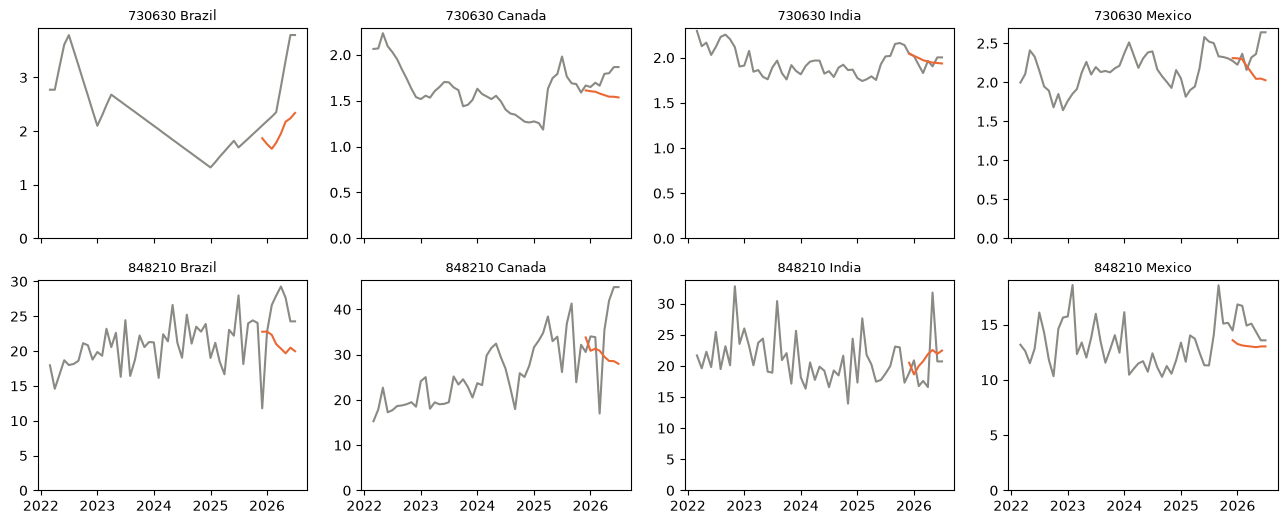

In [ ]:
g = pd.read_csv(os.path.join(os.getcwd(), "canada_prices.csv"))
g = g[g["Products and product groups"] == "Gasoline"]
g = g.set_index(pd.PeriodIndex(g["REF_DATE"], freq="M").to_timestamp())["VALUE"].asfreq("MS")

fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True)
for ax, ((hts, pais), d) in zip(axes.flat, df_price.groupby(["HTS Number", "Country"])):
    s = d.set_index("date")["usd_per_kg_landed"].reindex(g.index).interpolate().bfill()
    corte = int(len(s) * 0.85)
    f = ForecasterRecursive(Ridge(), lags=3)
    f.fit(y=s[:corte], exog=g[:corte])
    p = f.predict(steps=len(s) - corte, exog=g[corte:])
    ax.plot(s.index, s, color="#8a8983")
    ax.plot(p.index, p, color="#eb6834")
    ax.set_ylim(bottom=0)
    ax.set_title(f"{hts} {pais}", fontsize=9)

axes.flat[0].xaxis.set_major_locator(mdates.YearLocator())
axes.flat[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

#### It doesn't seem to me that there's a relationship among the data

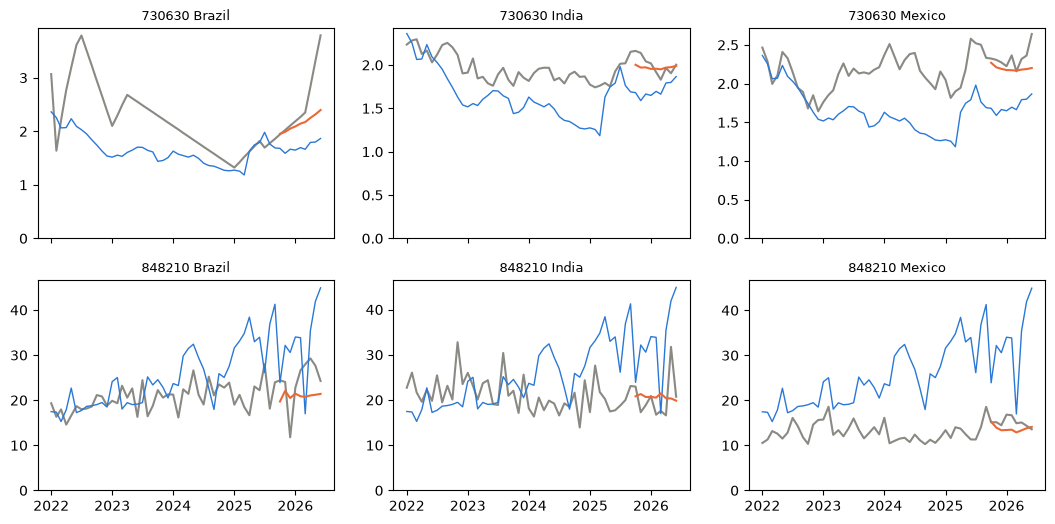

In [ ]:
ca = df_price[df_price["Country"] == "Canada"].pivot_table(
    index="date", columns="HTS Number", values="usd_per_kg_landed").asfreq("MS").bfill()
outros = df_price[df_price["Country"] != "Canada"]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
for ax, ((hts, pais), d) in zip(axes.flat, outros.groupby(["HTS Number", "Country"])):
    s = d.set_index("date")["usd_per_kg_landed"].reindex(ca.index).interpolate().bfill()
    g = ca[hts]
    corte = int(len(s) * 0.85)
    f = ForecasterRecursive(Ridge(), lags=3)
    f.fit(y=s[:corte], exog=g[:corte])
    p = f.predict(steps=len(s) - corte, exog=g[corte:])
    ax.plot(s.index, s, color="#8a8983")
    ax.plot(ca.index, g, color="#2a78d6", linewidth=1)
    ax.plot(p.index, p, color="#eb6834")
    ax.set_ylim(bottom=0)
    ax.set_title(f"{hts} {pais}", fontsize=9)

axes.flat[0].xaxis.set_major_locator(mdates.YearLocator())
axes.flat[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

#### Here it seems the predictor manages to approximate a moving average knowing Canada's data, even so it still has a lot of error, and the USD/kg data doesn't seem to be noisy

## 9. Volza vs. ImportYeti: agreement

Both sources read the same CBP maritime manifest, so any divergence between them is a sampling difference, not a factual one. Since the exporter ranking in section 4c comes only from Volza, this sample's size needs to be measured alongside it.

The test is to count each exporter's shipments on both sides, within the same window. ImportYeti's supplier bars are quarterly (only months 1, 4, 7, and 10), so the Volza window — 11/10/2025 to 02/04/2026 — can only be rounded outward, to Q4/2025 and Q1/2026. That's why the overall ratio comes out below 1 by construction: what matters is who shows up on both sides and whether the ranking order matches.

In [ ]:
VALID_INICIO = pd.Timestamp("2025-10-01")
VALID_FIM = pd.Timestamp("2026-03-31")

shipments_volza = pd.read_csv(VOLZA_CSV)
shipments_volza["hs6"] = shipments_volza["HS Code"].astype(str).str[:6]
shipments_volza["chave"] = [frozenset(marca(s)) for s in shipments_volza["Shipper"]]
shipments_p_brand_volza = (shipments_volza[pd.to_datetime(shipments_volza["Date"]).between(VALID_INICIO, VALID_FIM)]
         .groupby(["hs6", "chave"]).size())

shipments_yeti = pd.concat([pd.read_csv(os.path.join(os.getcwd(), f"importyeti_supplier_shipments_{h}.csv")).assign(hs6=h)
               for h in ["730630", "848210"]])
shipments_yeti["chave"] = [frozenset(marca(n)) for n in shipments_yeti["name"]]
shipments_p_brand_yeti = (shipments_yeti[pd.to_datetime(shipments_yeti["date"], format="%b %Y").between(VALID_INICIO, VALID_FIM)]
        .groupby(["hs6", "chave"])["shipments"].sum())#agregamos a quantidade de embarques por marca

conc = pd.concat([shipments_p_brand_yeti.rename("yeti"), shipments_p_brand_volza.rename("volza")], axis=1).fillna(0).astype(int)
print(conc.sort_values("yeti", ascending=False).to_string())

ambos = conc[(conc["yeti"] > 0) & (conc["volza"] > 0)]
resumo = pd.DataFrame({
    "yeti": [conc["yeti"].sum()],
    "volza": [conc["volza"].sum()],
    "razao": [conc["volza"].sum() / conc["yeti"].sum()],
    "nos_dois": [len(ambos)],
    "so_yeti": [int((conc["volza"] == 0).sum())],
    "so_volza": [int((conc["yeti"] == 0).sum())],
    "spearman": [ambos[["yeti", "volza"]].corr(method="spearman").iloc[0, 1]],
}).round(2)
print(resumo.head().to_string(index=False))

                                      yeti  volza
hs6    chave                                     
730630 (goodluck)                      298      0
       (investments)                   149      1
       (engitech, metamorphosis)        45      3
848210 (priv, agrasen)                  38      0
       (nrb)                            24      0
730630 (roshni, surya)                  24      0
       (privat, smith)                  23      0
       (apollo, metalex)                21      0
848210 (national)                       14      0
       (excellent)                      11      5
       (nachi)                          10      0
       (jtekt, latin)                   10      0
730630 (mex, ick, intercontinental)      8      2
848210 (austin)                          6      0
       (sudamericana, ntn)               4      0
       (monterrey, liebherr)             4      3
730630 (automotive, bend)                4      0
       (safewater, lines)                3      0


# Why Yeti doesn't exactly match Volza (even reading the "same" source)
Each provider does its own extraction, cleaning, and categorization of the same raw manifest
 
# Why DataWeb doesn't match Volza/ImportYeti
The maritime manifest (used by Volza and ImportYeti) only covers ocean freight; ImportYeti confirms that air and land freight records are not publicly available, which explains why Mexico and Canada appear so underrepresented in these two providers
